In [33]:
from fipy import (CellVariable, FaceVariable, Grid1D, DiffusionTerm, PowerLawConvectionTerm, ImplicitSourceTerm, TransientTerm, Viewer)
import numpy as np
import matplotlib.pyplot as plt

L = 1.0                    
px = 100
dx = L / nx
max_sweeps = 100
coupling_tolerance = 1e-8
L_ref = 1.0e-8             
T_ref = 300.0
n_ref = 1.0e28
V_ref = 2.0
Vapp = 1.0                 
kB = 1.380649e-23          
q  = 1.602176634e-19       
a_hop = 3.2e-10            
f_esc = 1e12               
Ea_eV = 0.85 

Ea = Ea_eV * q             
D0 = 0.5 * a_hop**2 * f_esc        
t_ref = L_ref**2 / D0              
E_ref = V_ref / L_ref               
v_ref = D0 / L_ref                  
Gamma_a = Ea / (kB * T_ref)
chi_E = q * a_hop * E_ref / (2.0 * kB * T_ref)
T_op = 300.0
theta_op = T_op / T_ref
T0_room = 293.0
theta_room = T0_room / T_ref

params = {"L_ref": L_ref, "T_ref": T_ref, "n_ref": n_ref, "V_ref": V_ref, "D0": D0, "t_ref": t_ref, "E_ref": E_ref, "v_ref": v_ref, "Gamma_a": Gamma_a, "chi_E": chi_E, "theta_op": theta_op, "theta_room": theta_room}
for name, value in params.items():
    print(f"{name:<10} = {value:.4e}")

L_ref      = 1.0000e-08
T_ref      = 3.0000e+02
n_ref      = 1.0000e+28
V_ref      = 2.0000e+00
D0         = 5.1200e-08
t_ref      = 1.9531e-09
E_ref      = 2.0000e+08
v_ref      = 5.1200e+00
Gamma_a    = 3.2879e+01
chi_E      = 1.2378e+00
theta_op   = 1.0000e+00
theta_room = 9.7667e-01


In [35]:
mesh = Grid1D(nx=nx, dx=dx)
X = mesh.cellCenters[0]
Phi = CellVariable(name="Dimensionless Electric Potential", mesh=mesh, value=np.sin(np.pi * X), hasOld=True)
theta = CellVariable(name="Dimensionless Temperature", mesh=mesh, value=np.ones_like(X), hasOld=True)
N = CellVariable(name="Dimensionless Vacancy Concentration", mesh=mesh, value=np.sin(np.pi * X), hasOld=True)

theta.constrain(theta_op, mesh.facesLeft)
theta.constrain(theta_op, mesh.facesRight)

Phi.constrain(0.0, mesh.facesLeft)
Phi.constrain(Vapp, mesh.facesRight)

N.faceGrad.constrain((0.,), mesh.facesLeft)
N.faceGrad.constrain((0.,), mesh.facesRight)

D_hat_op = np.exp(-Gamma_a / theta_op)
v_hat_op = ((a_hop / L_ref) * D_hat_op * np.sinh(chi_E * Vapp / theta_op))
v_hat_over_D_hat = v_hat_op / D_hat_op

d = dx / 2.0
fluxCoeff = FaceVariable(mesh=mesh, rank=1, value=(v_hat_over_D_hat,))
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 + v_hat_over_D_hat * d),), where=mesh.facesLeft)
fluxCoeff.setValue((2.0 * v_hat_over_D_hat / (1.0 - v_hat_over_D_hat * d),), where=mesh.facesRight)

In [36]:
rho = 8200.0
Cp  = 26.0
k_ref = 58.0

alpha_ref = k_ref / (rho * Cp)
alpha_ratio = alpha_ref / D0

lam_th = 0.1
Lambda_th = lam_th * T_ref

T0_room = 293.0
theta_room = T0_room / T_ref

def S_hat_of_theta(theta_value):
    return -Gamma_a / theta_value**2

def D_hat_of_theta(theta_value):
    return np.exp(-Gamma_a / theta_value)

def v_hat_of_theta_E(theta_value, E_hat_value):
    return ((2.0 * L_ref / a_hop) * np.exp(-Gamma_a / theta_value) * np.sinh(chi_E * E_hat_value / theta_value))

def nD_cm3_of_N(N_value):
    return N_value * n_ref * 1.0e-6

sigma_ref = 1.0e5          
nD_ref_cm3 = 1.0e22        
T0_PF = 293.0              

Gamma_el = sigma_ref * E_ref**2 * t_ref / (rho * Cp * T_ref)

def sigma0_of_nD(nD_cm3):
    return np.interp(nD_cm3, [1.0e16, 1.0e22], [1.0, 1.0e5])

_nD_pts_cm3 = np.array([1.0e16, 1.0e20, 5.0e21, 1.0e22])
_Eac_pts_eV = np.array([0.20, 0.10, 0.00, -0.006])

def Eac_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_cm3, _Eac_pts_eV)

kB_eV = 8.617333262e-5       

def Eac_hat_of_nD(nD_cm3):
    Eac_eV = Eac_of_nD(nD_cm3)
    return Eac_eV / (kB_eV * T0_PF)

alpha_PF = 5.48e-4
beta_PF  = -5.70

def sigma_PF_hat(E_hat_value, theta_value):
    E_Vm = np.abs(E_hat_value) * E_ref
    expo = (theta_room / theta_value) * (alpha_PF * np.sqrt(E_Vm) + beta_PF)
    return (1.0 / sigma_ref) * np.exp(np.minimum(expo, 30.0))

def sigma_hat_of_N_theta_E(N_value, theta_value, E_hat_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    sigma0_hat = (sigma0_of_nD(nD_cm3) / sigma_ref)
    Eac_hat = Eac_hat_of_nD(nD_cm3)
    sigma_arrhenius_hat = (sigma0_hat * np.exp(-Eac_hat * theta_room / theta_value))
    sigma_pf_hat = sigma_PF_hat(E_hat_value, theta_value)
    return (sigma_arrhenius_hat + sigma_pf_hat)

_nD_pts_kth_cm3 = [0.0, 1.0e22]
_kth0_pts = [0.0, 58.0]

def kth0_of_nD(nD_cm3):
    return np.interp(nD_cm3, _nD_pts_kth_cm3, _kth0_pts)

def k_hat_of_N_theta(N_value, theta_value):
    nD_cm3 = nD_cm3_of_N(N_value)
    kth0 = kth0_of_nD(nD_cm3)
    thermal_factor = (1.0 + Lambda_th * (theta_value - theta_room))
    return (kth0 / k_ref) * thermal_factor

D_hat_op = D_hat_of_theta(theta_op)
S_hat_op = S_hat_of_theta(theta_op)
E_hat_op = Vapp
v_hat_op = v_hat_of_theta_E(theta_op, E_hat_op)
sigma_hat_op = sigma_hat_of_N_theta_E(1.0, theta_op, E_hat_op)
k_hat_op = k_hat_of_N_theta(1.0, theta_op)

params = {"D_hat(theta_op)": D_hat_op, "S_hat(theta_op)": S_hat_op, "v_hat(theta_op,E_ref)": v_hat_op, "sigma_hat(N=1)": sigma_hat_op, "k_hat(N=1)": k_hat_op, "alpha_ref": alpha_ref, "alpha_ref / D0": alpha_ratio, "Lambda_th": Lambda_th, "theta_room": theta_room, "sigma_ref": sigma_ref, "Gamma_el": Gamma_el}
for name, value in params.items():
    print(f"{name:<23} = {value:.4e}")

D_hat(theta_op)         = 5.2557e-15
S_hat(theta_op)         = -3.2879e+01
v_hat(theta_op,E_ref)   = 5.1868e-13
sigma_hat(N=1)          = 1.2613e+00
k_hat(N=1)              = 1.7000e+00
alpha_ref               = 2.7205e-04
alpha_ref / D0          = 5.3134e+03
Lambda_th               = 3.0000e+01
theta_room              = 9.7667e-01
sigma_ref               = 1.0000e+05
Gamma_el                = 1.2215e+05


In [ ]:
dtau = 1.0e-3
final_tau = 1.0
n_time_steps = int(final_tau / dtau)

Phi.setValue(1.0 - X)
theta.setValue(1.0)
N.setValue(np.sin(np.pi * X))

def solve_electrical(N_val, theta_val, tol=1e-10, maxit=500):
    """Damped Picard solve of div(sigma(N,theta,E) grad Phi) = 0.
    The PF term makes sigma very steep in E, so an undamped iteration flips between two
    states (E ~ 10 <-> 30).  Adaptive damping on E fixes that.  Phi is reset to a linear
    profile before every linear solve (FiPy's LU can return an inexact answer when
    warm-started)."""
    E = (-Phi.grad[0]).value.copy()
    w, prev = 0.3, np.inf
    for it in range(maxit):
        s = CellVariable(mesh=mesh, value=sigma_hat_of_N_theta_E(N_val, theta_val, E))
        Phi.setValue(X)                                   
        DiffusionTerm(coeff=s.harmonicFaceValue, var=Phi).solve(var=Phi)
        E_new = (-Phi.grad[0]).value
        rel = np.linalg.norm(E_new - E) / (np.linalg.norm(E_new) + 1e-30)
        if rel < tol:
            break
        w = max(0.7 * w, 0.01) if rel > prev else min(1.05 * w, 0.5)
        prev = rel
        E = (1 - w) * E + w * E_new
    return it + 1

for time_step in range(n_time_steps):

    N.updateOld()
    theta.updateOld()
    
    converged = False

    for sweep in range(max_sweeps):

        Phi_iter = CellVariable(name="Phi iteration", mesh=mesh, value=Phi.value.copy())
        theta_iter = CellVariable(name="theta iteration", mesh=mesh, value=theta.value.copy())
        N_iter = CellVariable(name="N iteration", mesh=mesh, value=N.value.copy())

        E_hat_value = (-Phi_iter.grad[0]).value
        D_hat_value = D_hat_of_theta(theta_iter.value)
        S_hat_value = S_hat_of_theta(theta_iter.value)
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        D_hat = CellVariable(name="D_hat", mesh=mesh, rank=0, value=D_hat_value)
        S_hat = CellVariable(name="S_hat", mesh=mesh, rank=0, value=S_hat_value)
        solve_electrical(N_iter.value, theta_iter.value)

        E_hat_value = (-Phi.grad[0]).value
        v_hat_value = v_hat_of_theta_E(theta_iter.value, E_hat_value)
        E_hat_face = -Phi.faceGrad[0]
        theta_face = theta_iter.faceValue
        v_hat_face_value = v_hat_of_theta_E(theta_face.value, E_hat_face.value)
        v_hat = FaceVariable(name="v_hat", mesh=mesh, rank=1, value=(v_hat_face_value,))
        diffusion_term = DiffusionTerm(coeff=D_hat, var=N)
        drift_term = PowerLawConvectionTerm(coeff=v_hat, var=N)
        soret_coeff_value = (D_hat_value * S_hat_value * N_iter.value)
        soret_coeff = CellVariable(name="Soret coefficient", mesh=mesh, rank=0, value=soret_coeff_value)
        soret_term = DiffusionTerm(coeff=soret_coeff, var=theta)
        ambipolar_eq = (TransientTerm(var=N) == diffusion_term - drift_term + soret_term)
        ambipolar_eq.solve(var=N, dt=dtau)

        Jp_hat = (N.value * v_hat_value - D_hat_value * N.grad[0].value)
        sigma_hat_joule = sigma_hat_of_N_theta_E(N_iter.value, theta_iter.value, E_hat_value)
        heat_source_hat_value = Gamma_el * sigma_hat_joule * E_hat_value**2
        heat_source_hat = CellVariable(name="Dimensionless Joule Heating Source", mesh=mesh, rank=0, value=heat_source_hat_value)
        k_hat_value = k_hat_of_N_theta(N_iter.value, theta_iter.value)
        k_hat_value = np.maximum(k_hat_value, 1.0e-10)
        k_hat = CellVariable(name="k_hat", mesh=mesh, rank=0, value=k_hat_value)
        heat_eq = (TransientTerm(var=theta) == DiffusionTerm(coeff=alpha_ratio * k_hat, var=theta) + heat_source_hat)
        heat_eq.solve(var=theta, dt=dtau)

        Phi_change = np.max(np.abs(Phi.value - Phi_iter.value))
        theta_change = np.max(np.abs(theta.value - theta_iter.value))
        N_change = np.max(np.abs(N.value - N_iter.value))
        max_change = max(Phi_change, theta_change, N_change)

        del Phi_iter
        del theta_iter
        del N_iter

        if max_change < coupling_tolerance:
            converged = True
            break

    if not converged:
        print(f"WARNING: coupling did not converge " f"at time step {time_step + 1}")
        print(f"Final coupling change = " f"{max_change:.4e}")
        break

print("Transient simulation finished.")
print(f"Final dimensionless time = " f"{(time_step + 1) * dtau:.4e}")
print(f"Final physical time = " f"{(time_step + 1) * dtau * t_ref:.4e} s")

Transient simulation finished.
Final dimensionless time = 1.0000e+00
Final physical time = 1.9531e-09 s


In [38]:
Phi_values = Phi.value.copy()
E_hat_values = Phi.grad[0]
E_hat_final = CellVariable(name="Dimensionless Electric Field", mesh=mesh, value=-E_hat_values)
dN_dX_final = N.grad[0]
D_hat_final = D_hat_of_theta(theta.value)
S_hat_final = S_hat_of_theta(theta.value)
v_hat_final = v_hat_of_theta_E(theta.value, E_hat_final.value)
Jp_hat_final = (N.value * v_hat_final - D_hat_final * dN_dX_final.value)
Q_hat_final = Gamma_el * sigma_hat_of_N_theta_E(N.value, theta.value, E_hat_final.value) * E_hat_final.value**2

results = {"Dimensionless electric potential (Phi)": Phi.value, "Dimensionless electric field (E_hat)": E_hat_final.value, "Dimensionless temperature (theta)": theta.value, "Dimensionless vacancy concentration (N)": N.value, "Dimensionless vacancy current (Jp_hat)": Jp_hat_final, "Dimensionless Joule heating (Q_hat)": Q_hat_final}
for name, data in results.items():
    print(f"{name}: " f"min = {np.min(data):.4e}, " f"max = {np.max(data):.4e}")

Dimensionless electric potential (Phi): min = 1.9051e-02, max = 9.8095e-01
Dimensionless electric field (E_hat): min = -4.3131e+00, max = -1.4976e-01
Dimensionless temperature (theta): min = 1.1221e+00, max = 1.3014e+00
Dimensionless vacancy concentration (N): min = 1.5707e-02, max = 9.9988e-01
Dimensionless vacancy current (Jp_hat): min = -1.8243e-09, max = -6.9030e-12
Dimensionless Joule heating (Q_hat): min = 3.2736e+03, max = 9.5088e+04


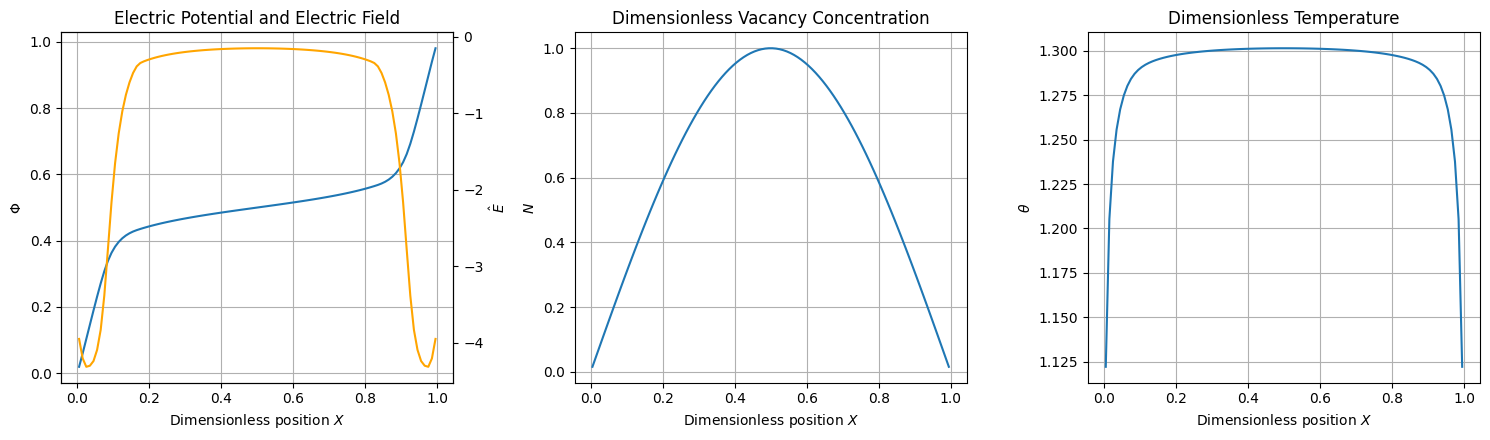

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
ax1 = axes[0]
ax1.plot(X, Phi.value)
ax1.set_xlabel(r'Dimensionless position $X$')
ax1.set_ylabel(r'$\Phi$')
ax1.set_title('Electric Potential and Electric Field')
ax1.grid(True)
ax1_E = ax1.twinx()
ax1_E.plot(X, E_hat_final, color='orange')
ax1_E.set_ylabel(r'$\hat{E}$')
ax1_E.ticklabel_format(useOffset=False, style='plain')

for ax, y, ylabel, title in [(axes[1], N.value, r'$N$', 'Dimensionless Vacancy Concentration'), (axes[2], theta.value, r'$\theta$', 'Dimensionless Temperature')]:
    ax.plot(X, y)
    ax.set(xlabel=r'Dimensionless position $X$', ylabel=ylabel, title=title)
    ax.grid(True)
plt.tight_layout()
plt.show()

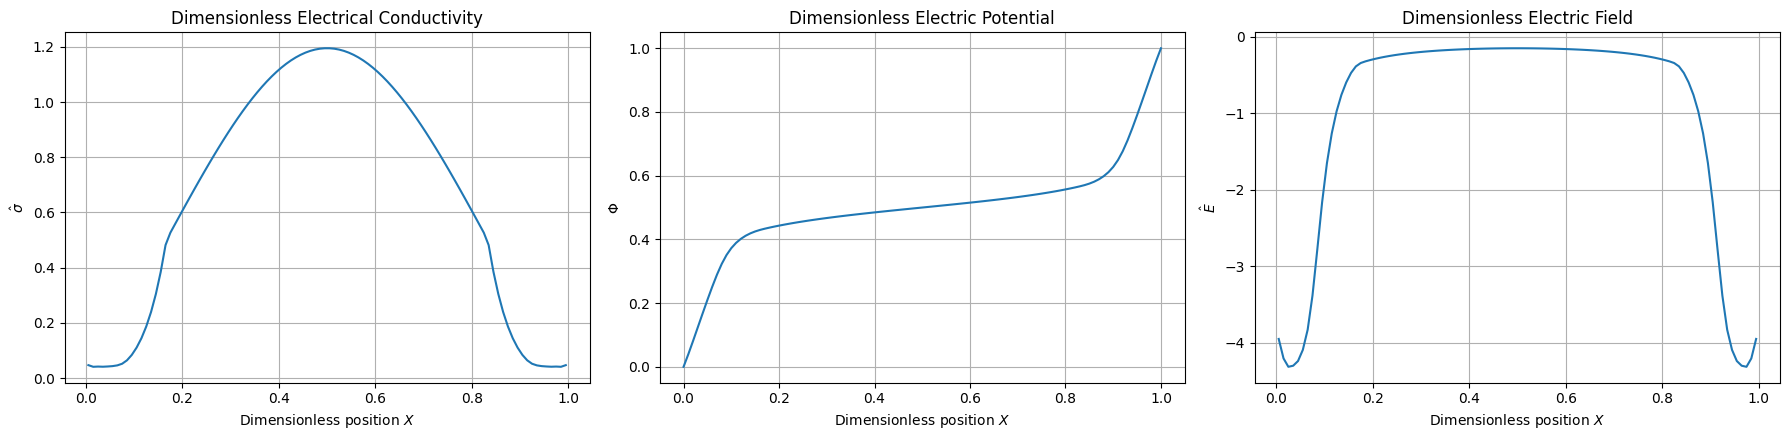

In [40]:
sigma_final = sigma_hat_of_N_theta_E(N.value, theta.value, E_hat_final.value)
X_face = mesh.faceCenters[0].value
Phi_face = Phi.faceValue.value
X_cell = mesh.cellCenters[0].value
E_cell = -Phi.grad[0].value

fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
axes[0].plot(X, sigma_final)
axes[0].set_xlabel(r'Dimensionless position $X$')
axes[0].set_ylabel(r'$\hat{\sigma}$')
axes[0].set_title('Dimensionless Electrical Conductivity')
axes[0].grid(True)

axes[1].plot(X_face, Phi_face)
axes[1].set_xlabel(r'Dimensionless position $X$')
axes[1].set_ylabel(r'$\Phi$')
axes[1].set_title('Dimensionless Electric Potential')
axes[1].grid(True)

axes[2].plot(X_cell, E_cell)
axes[2].set_xlabel(r'Dimensionless position $X$')
axes[2].set_ylabel(r'$\hat{E}$')
axes[2].set_title('Dimensionless Electric Field')
axes[2].grid(True)
plt.tight_layout()
plt.show()

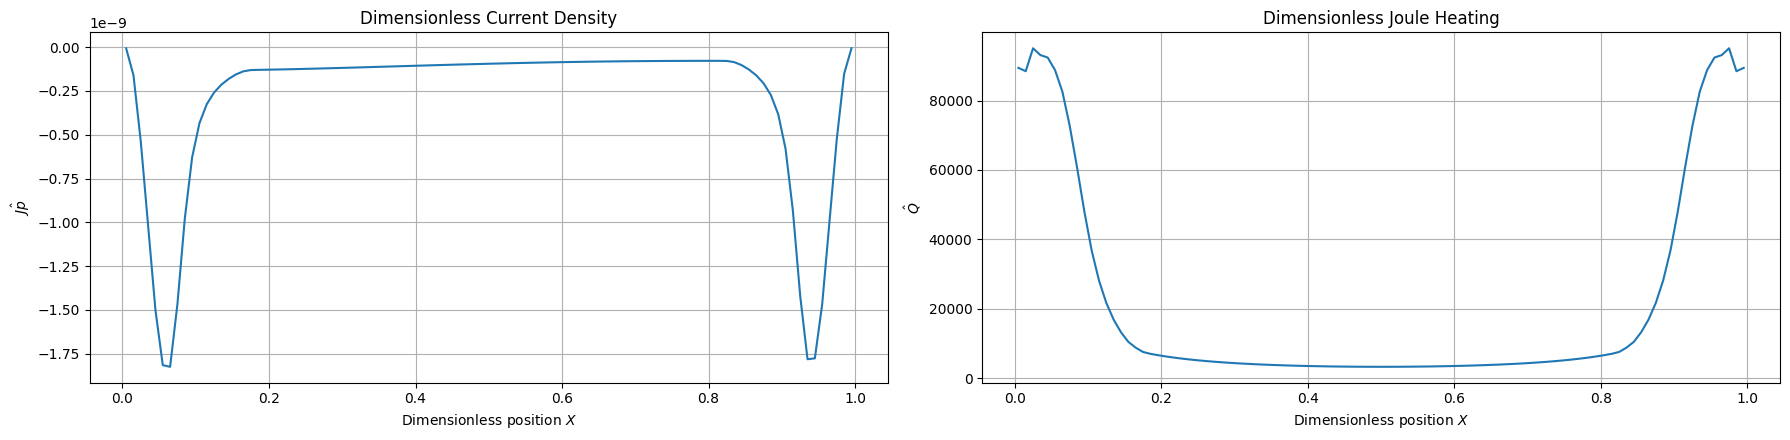

In [41]:
Jp_hat_final = (N.value * v_hat_final - D_hat_final * dN_dX_final.value)
Q_hat_final = Gamma_el * sigma_hat_of_N_theta_E(N.value, theta.value, E_hat_final.value) * E_hat_final.value**2

fig, axes = plt.subplots(1, 2, figsize=(18, 4.5))
axes[0].plot(X, Jp_hat_final)
axes[0].set_xlabel(r'Dimensionless position $X$')
axes[0].set_ylabel(r'$\hat{Jp}$')
axes[0].set_title('Dimensionless Current Density')
axes[0].grid(True)

axes[1].plot(X, Q_hat_final)
axes[1].set_xlabel(r'Dimensionless position $X$')
axes[1].set_ylabel(r'$\hat{Q}$')
axes[1].set_title('Dimensionless Joule Heating')
axes[1].grid(True)
plt.tight_layout()
plt.show()